# 🎗️ Breast Cancer Prediction — Machine Learning Project

This notebook walks through a full ML workflow for predicting **breast cancer** from patient health & lifestyle data:

1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Cleaning
4. Feature Engineering
5. Data Visualization
6. Preprocessing
7. Model Training & Comparison
8. Prediction on New Data

---

##  Import Libraries

In [1]:
# importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

##  Load the Dataset

In [2]:
# #importing the dataset
df = pd.read_csv("breast_cancer_prediction.csv")

In [3]:
df.head()

,Patient_ID,Age,Gender,BMI,Family_History,Smoking,Alcohol_Consumption,Physical_Activity,Hormone_Therapy,Menopause_Status,...,Mammogram_Result,Biopsy_Result,Cancer_Stage,Cancer,Blood_Pressure,Cholesterol,Diabetes,Exercise_Days_Per_Week,Breastfeeding_History,Annual_Income_USD
0,100001,71,Female,27.2,Yes,Yes,Yes,High,No,Post,...,Suspicious,Malignant,Stage II,1,141,167,No,7,No,101316
1,100002,34,Male,26.0,No,No,No,High,No,Post,...,Normal,Benign,No Cancer,0,104,229,Yes,7,Yes,30023
2,100003,80,Female,20.7,No,No,No,High,No,Pre,...,Suspicious,Benign,No Cancer,0,161,275,No,1,Yes,34819
3,100004,40,Female,26.8,Yes,Yes,No,Moderate,No,Post,...,Normal,Benign,No Cancer,0,150,180,No,7,Yes,68025
4,100005,43,Female,28.6,Yes,Yes,No,Moderate,No,Post,...,Normal,Benign,No Cancer,0,110,266,No,0,Yes,90919


##  Exploratory Data Analysis (EDA)

Let's look at the categorical and numerical columns, check data types, and identify missing values.

In [4]:
Categorical_data = df.select_dtypes(include= "object")


for i in Categorical_data:
    print(i)
    print(df[i].value_counts())

Gender
Gender
Female    9277
Male       723
Name: count, dtype: int64
Family_History
Family_History
No     6979
Yes    3021
Name: count, dtype: int64
Smoking
Smoking
No     7462
Yes    2538
Name: count, dtype: int64
Alcohol_Consumption
Alcohol_Consumption
No     6319
Yes    3381
Name: count, dtype: int64
Physical_Activity
Physical_Activity
Moderate    4379
Low         2876
High        2445
Name: count, dtype: int64
Hormone_Therapy
Hormone_Therapy
No     7704
Yes    1996
Name: count, dtype: int64
Menopause_Status
Menopause_Status
Post    5509
Pre     4491
Name: count, dtype: int64
Genetic_Mutation
Genetic_Mutation
Negative    8542
Positive    1458
Name: count, dtype: int64
Lymph_Node_Involvement
Lymph_Node_Involvement
No     7977
Yes    2023
Name: count, dtype: int64
Mammogram_Result
Mammogram_Result
Normal        6481
Suspicious    2017
Abnormal      1502
Name: count, dtype: int64
Biopsy_Result
Biopsy_Result
Benign       8067
Malignant    1933
Name: count, dtype: int64
Cancer_Stage
Can

In [5]:
Numerical_data = df.select_dtypes(include= "number")


for i in Numerical_data:
    print(i)
    print(df[i].value_counts())

Patient_ID
Patient_ID
100001    1
100002    1
100003    1
100004    1
100005    1
         ..
109996    1
109997    1
109998    1
109999    1
110000    1
Name: count, Length: 10000, dtype: int64
Age
Age
36    190
32    180
45    179
40    177
81    176
     ... 
60    135
65    134
24    133
53    132
26    131
Name: count, Length: 65, dtype: int64
BMI
BMI
27.0    97
26.8    96
25.7    95
29.4    93
26.7    93
        ..
43.6     1
17.2     1
38.2     1
13.6     1
13.8     1
Name: count, Length: 280, dtype: int64
Tumor_Size_cm
Tumor_Size_cm
2.42    34
2.06    32
1.79    31
2.50    31
3.14    31
        ..
5.81     1
8.67     1
9.88     1
8.52     1
7.27     1
Name: count, Length: 728, dtype: int64
Cancer
Cancer
0    8067
1    1933
Name: count, dtype: int64
Blood_Pressure
Blood_Pressure
106    138
151    131
176    128
143    127
115    127
      ... 
139     94
120     93
172     93
96      88
180     79
Name: count, Length: 91, dtype: int64
Cholesterol
Cholesterol
144    86
241    84


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Patient_ID              10000 non-null  int64  
 1   Age                     10000 non-null  int64  
 2   Gender                  10000 non-null  object 
 3   BMI                     9700 non-null   float64
 4   Family_History          10000 non-null  object 
 5   Smoking                 10000 non-null  object 
 6   Alcohol_Consumption     9700 non-null   object 
 7   Physical_Activity       9700 non-null   object 
 8   Hormone_Therapy         9700 non-null   object 
 9   Menopause_Status        10000 non-null  object 
 10  Genetic_Mutation        10000 non-null  object 
 11  Tumor_Size_cm           9700 non-null   float64
 12  Lymph_Node_Involvement  10000 non-null  object 
 13  Mammogram_Result        10000 non-null  object 
 14  Biopsy_Result           10000 non-null 

In [7]:
df.isnull().sum()

Patient_ID                  0
Age                         0
Gender                      0
BMI                       300
Family_History              0
Smoking                     0
Alcohol_Consumption       300
Physical_Activity         300
Hormone_Therapy           300
Menopause_Status            0
Genetic_Mutation            0
Tumor_Size_cm             300
Lymph_Node_Involvement      0
Mammogram_Result            0
Biopsy_Result               0
Cancer_Stage                0
Cancer                      0
Blood_Pressure              0
Cholesterol                 0
Diabetes                    0
Exercise_Days_Per_Week      0
Breastfeeding_History       0
Annual_Income_USD           0
dtype: int64

In [8]:
df.shape

(10000, 23)

##  Data Cleaning — Handle Missing Values

Numeric columns are filled with their **mean**, and categorical columns are filled with their **mode**.

In [9]:
df["BMI"].fillna(df["BMI"].mean(), inplace= True)
df["Alcohol_Consumption"].fillna(df["Alcohol_Consumption"].mode()[0], inplace= True)
df["Physical_Activity"].fillna(df["Physical_Activity"].mode()[0], inplace= True)
df["Hormone_Therapy"].fillna(df["Hormone_Therapy"].mode()[0], inplace= True)
df["Tumor_Size_cm"].fillna(df["Tumor_Size_cm"].mean(), inplace= True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Patient_ID              10000 non-null  int64  
 1   Age                     10000 non-null  int64  
 2   Gender                  10000 non-null  object 
 3   BMI                     10000 non-null  float64
 4   Family_History          10000 non-null  object 
 5   Smoking                 10000 non-null  object 
 6   Alcohol_Consumption     10000 non-null  object 
 7   Physical_Activity       10000 non-null  object 
 8   Hormone_Therapy         10000 non-null  object 
 9   Menopause_Status        10000 non-null  object 
 10  Genetic_Mutation        10000 non-null  object 
 11  Tumor_Size_cm           10000 non-null  float64
 12  Lymph_Node_Involvement  10000 non-null  object 
 13  Mammogram_Result        10000 non-null  object 
 14  Biopsy_Result           10000 non-null 

In [11]:
df.describe()

,Patient_ID,Age,BMI,Tumor_Size_cm,Cancer,Blood_Pressure,Cholesterol,Exercise_Days_Per_Week,Annual_Income_USD
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,105000.50000,52.033800,27.051227,2.630334,0.193300,134.811100,214.071500,3.535200,82337.305000
std,2886.89568,18.789517,4.426563,1.565759,0.394906,26.174742,49.242034,2.282385,39102.629984
min,100001.00000,20.000000,11.100000,0.000000,0.000000,90.000000,130.000000,0.000000,15002.000000
25%,102500.75000,36.000000,24.100000,1.400000,0.000000,112.000000,172.000000,2.000000,48145.750000
50%,105000.50000,52.000000,27.051227,2.570000,0.000000,135.000000,213.000000,4.000000,81813.500000
75%,107500.25000,68.000000,30.000000,3.680000,0.000000,157.000000,257.000000,6.000000,116217.500000
max,110000.00000,84.000000,44.100000,9.880000,1.000000,180.000000,300.000000,7.000000,149996.000000


##  Feature Engineering — Create Categorical Bins

Continuous medical measurements (BMI, Blood Pressure, Cholesterol, Tumor Size) are converted into meaningful **categories** for easier interpretation and analysis.

In [12]:
def BMI_Category(BMI):
    if BMI < 18.5:
        return "Underweight" 
    elif BMI >= 18.5 and BMI < 24.9:
        return "Healthy (Normal)"
    elif BMI >= 25 and BMI < 29.9:
        return "Overweight" 
    elif BMI >= 30 and BMI < 34.9:
        return "Obesity Class I" 
    elif BMI >= 35 and BMI < 39.9: 
        return "Obesity Class II"
    else:
        return "Obesity Class III"

df["BMI_Category"] = df["BMI"].apply(BMI_Category)

In [13]:
def Blood_Pressure_Category(Blood_Pressure):
    if Blood_Pressure < 90:
        return "Low"
    elif Blood_Pressure < 120:
        return "Normal"
    elif Blood_Pressure < 130:
        return "Elevated"
    elif Blood_Pressure < 140:
        return "High"
    else:
        return "Very High"

df["Blood_Pressure_Category"] = df["Blood_Pressure"].apply(Blood_Pressure_Category)

In [14]:
def Cholesterol_Category(Cholesterol):
    if Cholesterol < 200:
        return "Desirable"
    elif Cholesterol < 239:
        return "Borderline High"
    else: 
        return "High"

df["Cholesterol_Category"] = df["Cholesterol"].apply(Cholesterol_Category)

In [15]:
def Tumor_Size_Category(Tumor_Size_cm):
    if Tumor_Size_cm < 2:
        return "Small"
    elif Tumor_Size_cm < 5:
        return "Medium"
    else:
        return "Large"

df["Tumor_Size_Category"] = df["Tumor_Size_cm"].apply(Tumor_Size_Category)

In [16]:
df

,Patient_ID,Age,Gender,BMI,Family_History,Smoking,Alcohol_Consumption,Physical_Activity,Hormone_Therapy,Menopause_Status,...,Blood_Pressure,Cholesterol,Diabetes,Exercise_Days_Per_Week,Breastfeeding_History,Annual_Income_USD,BMI_Category,Blood_Pressure_Category,Cholesterol_Category,Tumor_Size_Category
0,100001,71,Female,27.2,Yes,Yes,Yes,High,No,Post,...,141,167,No,7,No,101316,Overweight,Very High,Desirable,Medium
1,100002,34,Male,26.0,No,No,No,High,No,Post,...,104,229,Yes,7,Yes,30023,Overweight,Normal,Borderline High,Medium
2,100003,80,Female,20.7,No,No,No,High,No,Pre,...,161,275,No,1,Yes,34819,Healthy (Normal),Very High,High,Medium
3,100004,40,Female,26.8,Yes,Yes,No,Moderate,No,Post,...,150,180,No,7,Yes,68025,Overweight,Very High,Desirable,Small
4,100005,43,Female,28.6,Yes,Yes,No,Moderate,No,Post,...,110,266,No,0,Yes,90919,Overweight,Normal,High,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,109996,84,Female,31.4,No,No,Yes,High,No,Post,...,117,166,No,5,Not Applicable,46779,Obesity Class I,Normal,Desirable,Small
9996,109997,43,Female,24.7,No,Yes,No,Moderate,Yes,Pre,...,116,169,No,7,No,110807,Healthy (Normal),Normal,Desirable,Small
9997,109998,23,Female,26.2,Yes,No,Yes,Moderate,No,Pre,...,140,214,No,6,No,126164,Overweight,Very High,Borderline High,Small
9998,109999,44,Female,21.8,No,No,No,Moderate,No,Post,...,153,175,No,4,Not Applicable,89761,Healthy (Normal),Very High,Desirable,Medium


##  Data Visualization

Visualizing distributions of key categorical features using pie charts and count plots, followed by a correlation heatmap.

In [17]:
px.pie(df, names= "BMI_Category", title= "BMI Category Distribution", hole= 0.5)

In [18]:
px.pie(df, names= "Blood_Pressure_Category", title= "Blood Pressure Category Distribution", hole= 0.5)

In [19]:
px.pie(df, names= "Cholesterol_Category", title= "Cholesterol Category Distribution", hole= 0.5)

In [20]:
px.pie(df, names= "Gender", title= "Gender Distribution", hole= 0.5)

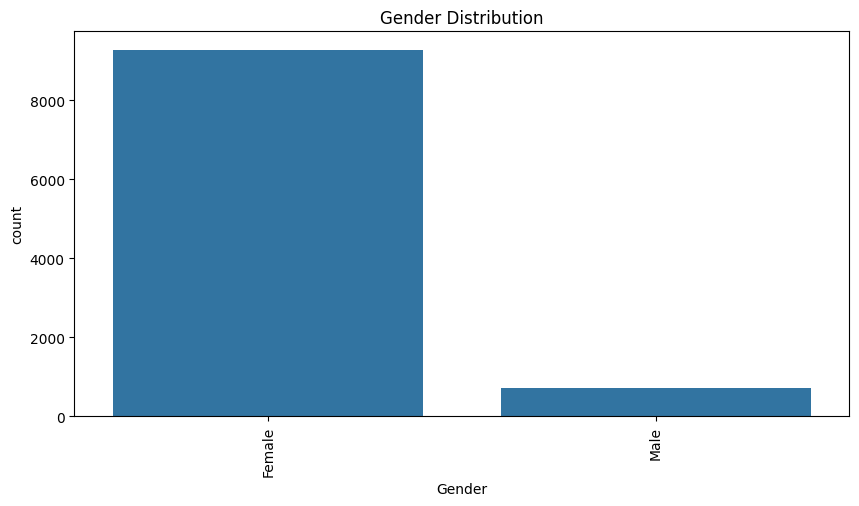

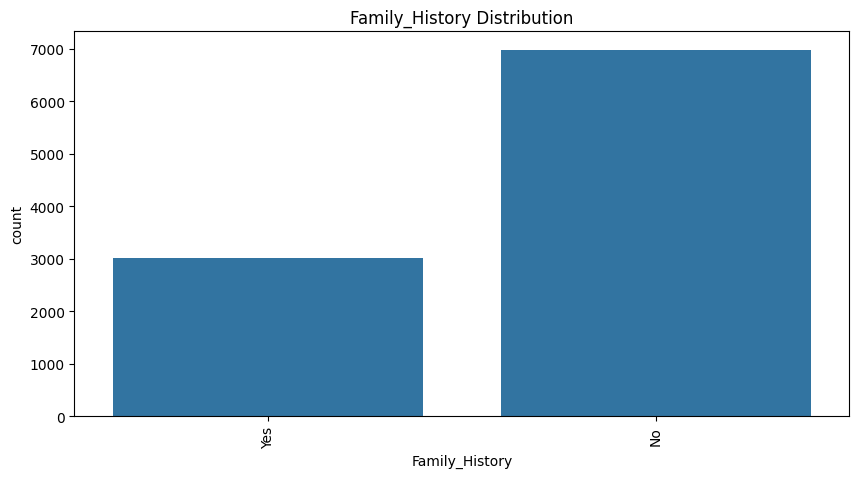

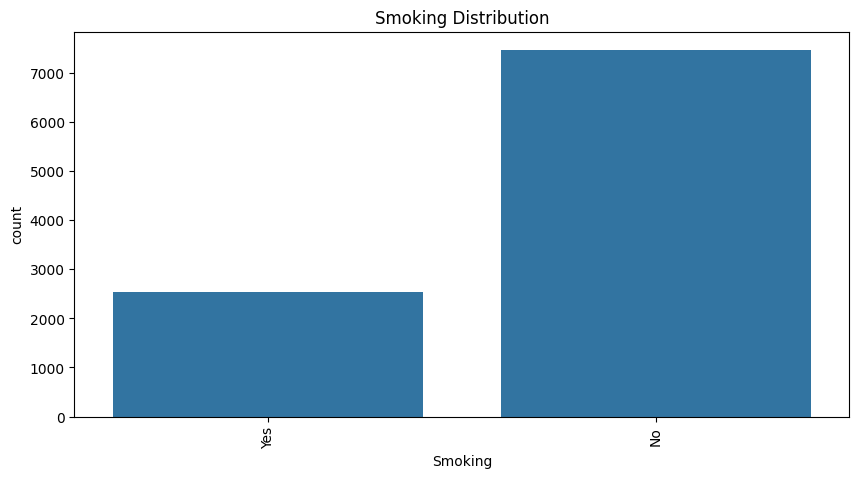

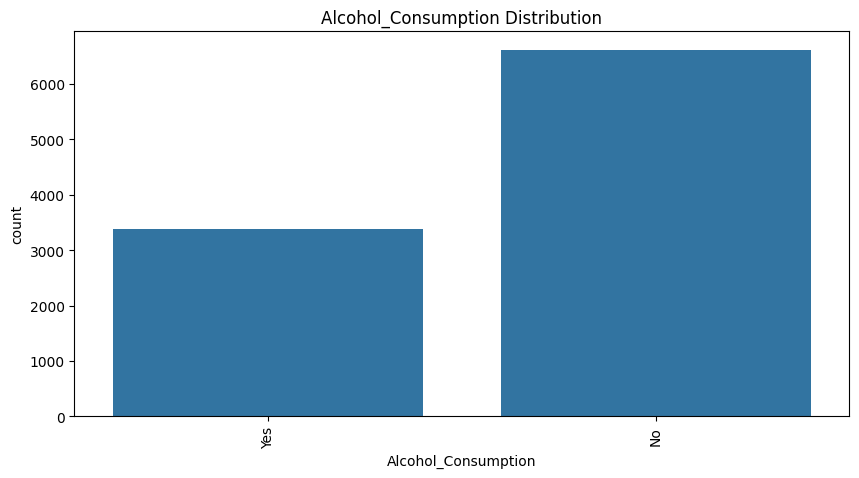

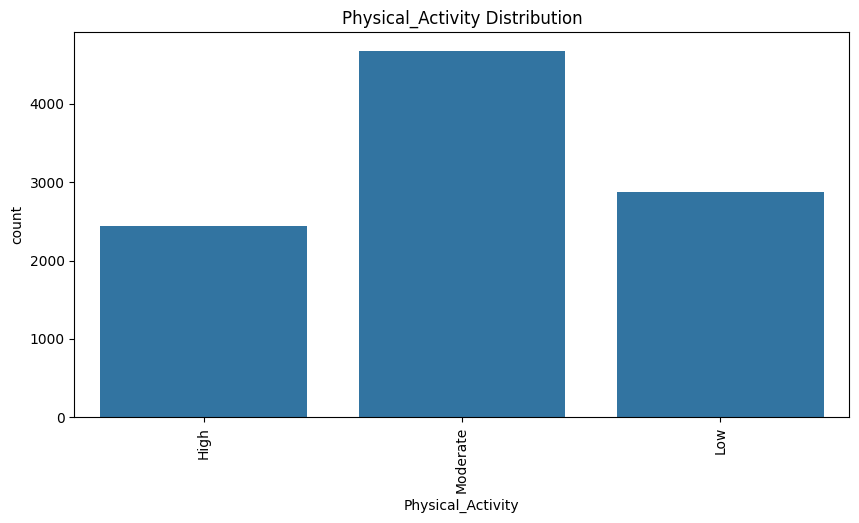

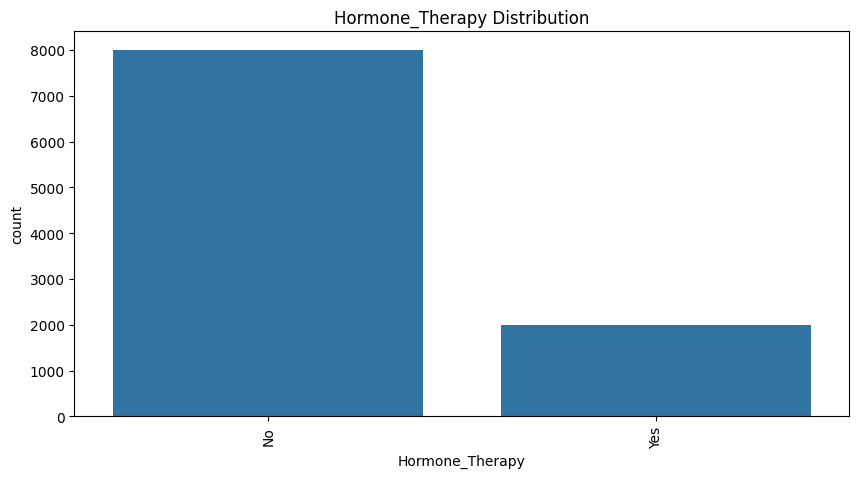

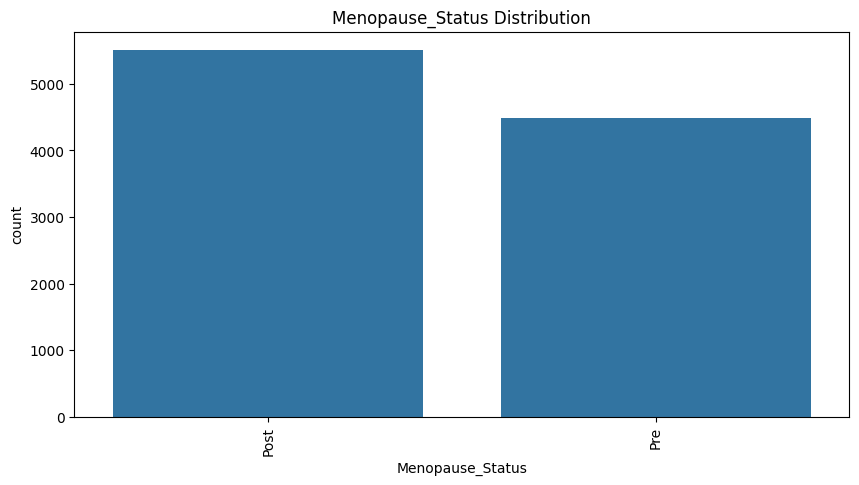

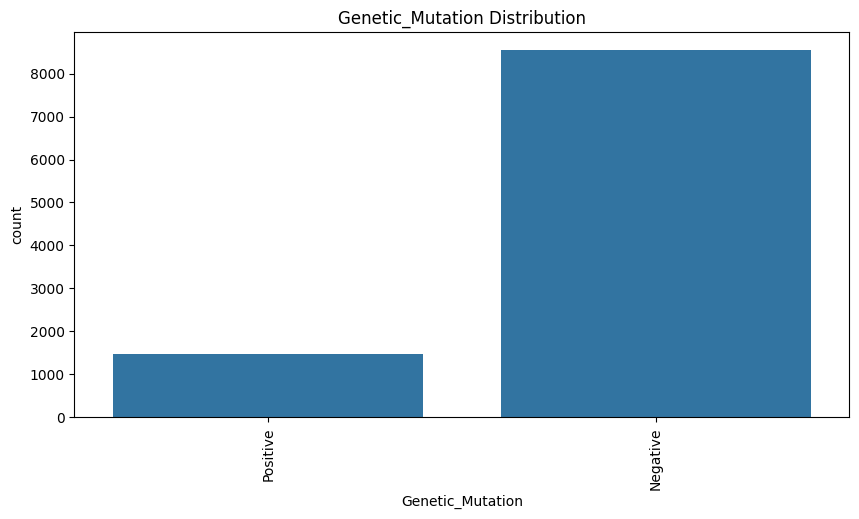

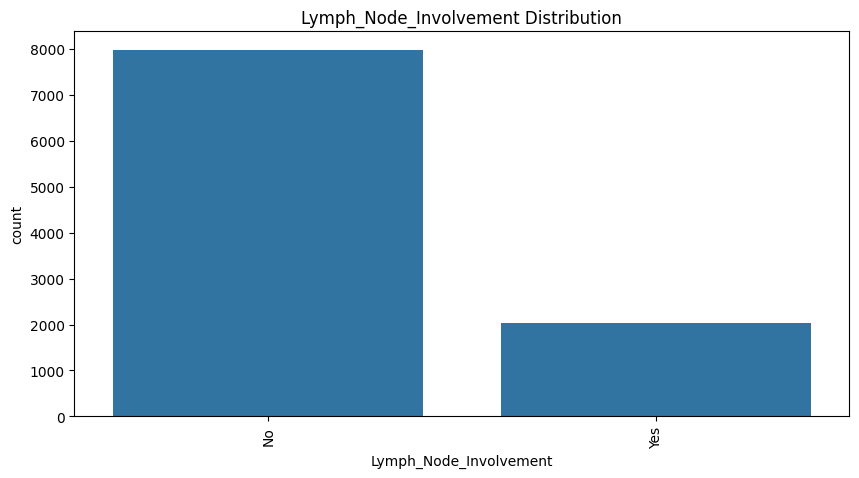

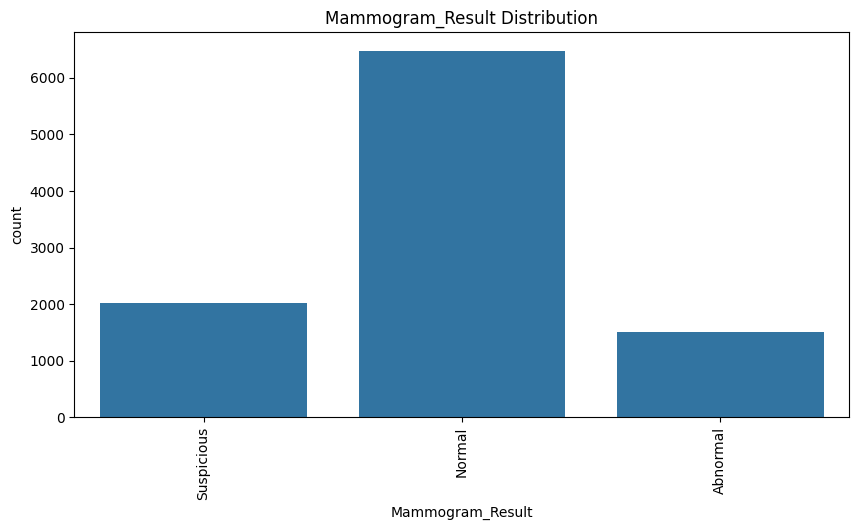

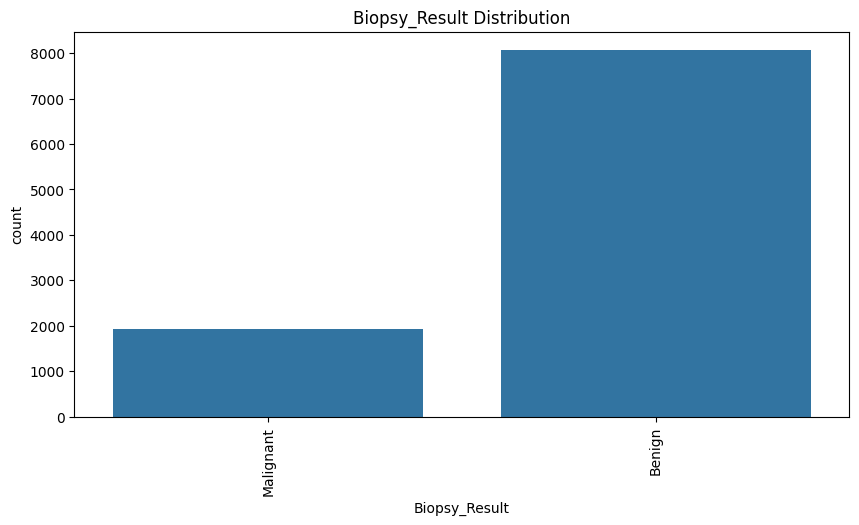

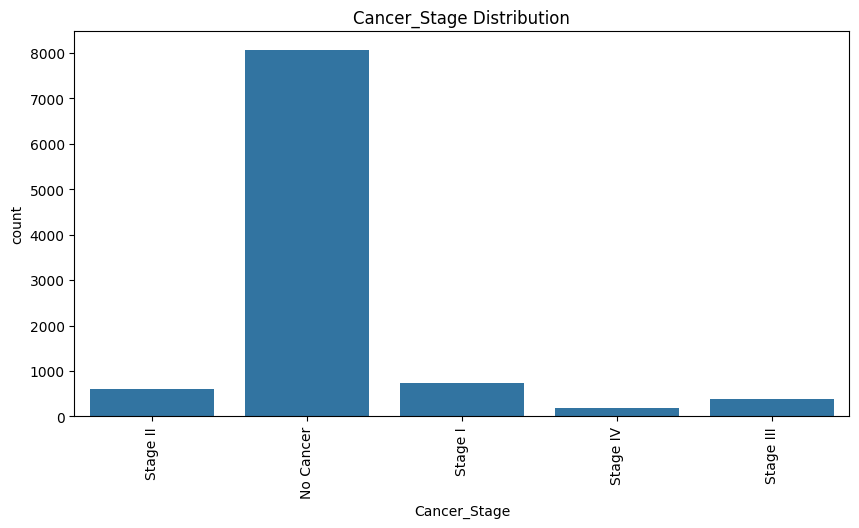

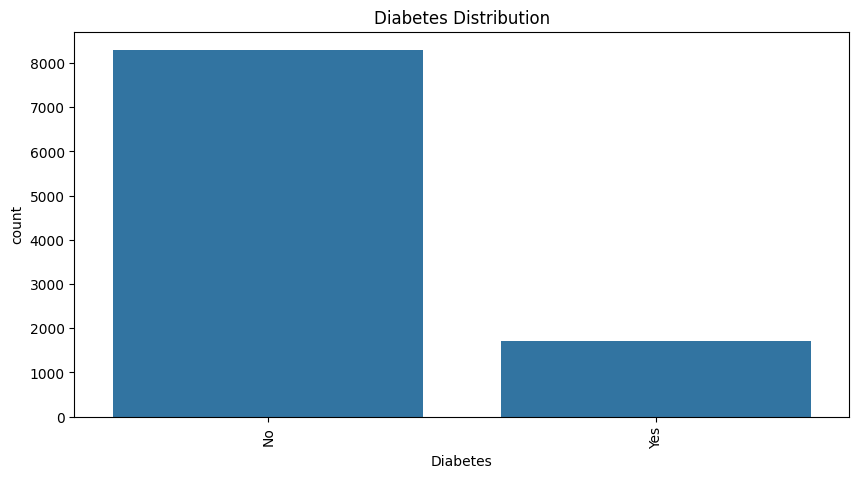

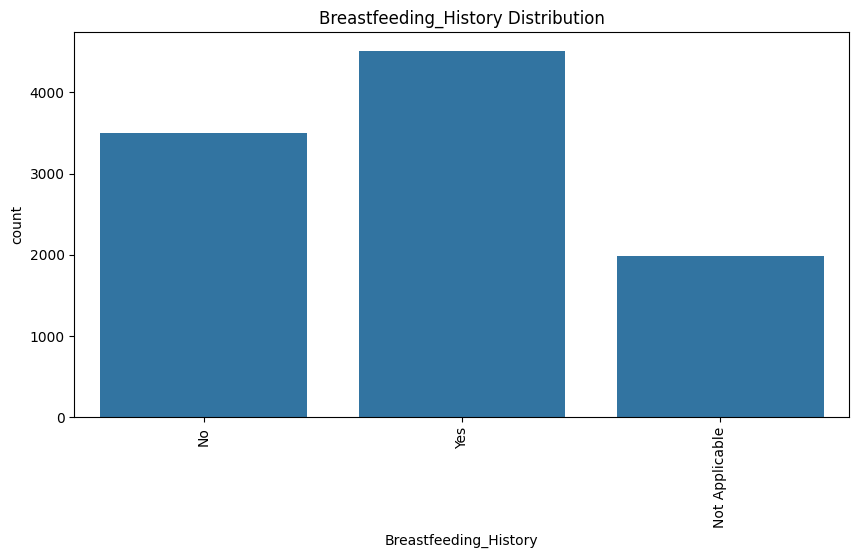

In [21]:
for i in Categorical_data:
    plt.figure(figsize= (10, 5))
    sns.countplot(x= i, data= df)
    plt.title(f"{i} Distribution")
    plt.xticks(rotation= 90)
    plt.show()

In [22]:
df

,Patient_ID,Age,Gender,BMI,Family_History,Smoking,Alcohol_Consumption,Physical_Activity,Hormone_Therapy,Menopause_Status,...,Blood_Pressure,Cholesterol,Diabetes,Exercise_Days_Per_Week,Breastfeeding_History,Annual_Income_USD,BMI_Category,Blood_Pressure_Category,Cholesterol_Category,Tumor_Size_Category
0,100001,71,Female,27.2,Yes,Yes,Yes,High,No,Post,...,141,167,No,7,No,101316,Overweight,Very High,Desirable,Medium
1,100002,34,Male,26.0,No,No,No,High,No,Post,...,104,229,Yes,7,Yes,30023,Overweight,Normal,Borderline High,Medium
2,100003,80,Female,20.7,No,No,No,High,No,Pre,...,161,275,No,1,Yes,34819,Healthy (Normal),Very High,High,Medium
3,100004,40,Female,26.8,Yes,Yes,No,Moderate,No,Post,...,150,180,No,7,Yes,68025,Overweight,Very High,Desirable,Small
4,100005,43,Female,28.6,Yes,Yes,No,Moderate,No,Post,...,110,266,No,0,Yes,90919,Overweight,Normal,High,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,109996,84,Female,31.4,No,No,Yes,High,No,Post,...,117,166,No,5,Not Applicable,46779,Obesity Class I,Normal,Desirable,Small
9996,109997,43,Female,24.7,No,Yes,No,Moderate,Yes,Pre,...,116,169,No,7,No,110807,Healthy (Normal),Normal,Desirable,Small
9997,109998,23,Female,26.2,Yes,No,Yes,Moderate,No,Pre,...,140,214,No,6,No,126164,Overweight,Very High,Borderline High,Small
9998,109999,44,Female,21.8,No,No,No,Moderate,No,Post,...,153,175,No,4,Not Applicable,89761,Healthy (Normal),Very High,Desirable,Medium


##  Preprocessing — Drop Redundant Columns

Now that categorical bins have been created, the original raw numeric columns (and the ID column) are no longer needed.

In [23]:
df = df.drop(["Patient_ID", "BMI", "Blood_Pressure", "Cholesterol", "Tumor_Size_cm"], axis=1)

In [24]:
df

,Age,Gender,Family_History,Smoking,Alcohol_Consumption,Physical_Activity,Hormone_Therapy,Menopause_Status,Genetic_Mutation,Lymph_Node_Involvement,...,Cancer_Stage,Cancer,Diabetes,Exercise_Days_Per_Week,Breastfeeding_History,Annual_Income_USD,BMI_Category,Blood_Pressure_Category,Cholesterol_Category,Tumor_Size_Category
0,71,Female,Yes,Yes,Yes,High,No,Post,Positive,No,...,Stage II,1,No,7,No,101316,Overweight,Very High,Desirable,Medium
1,34,Male,No,No,No,High,No,Post,Negative,No,...,No Cancer,0,Yes,7,Yes,30023,Overweight,Normal,Borderline High,Medium
2,80,Female,No,No,No,High,No,Pre,Negative,No,...,No Cancer,0,No,1,Yes,34819,Healthy (Normal),Very High,High,Medium
3,40,Female,Yes,Yes,No,Moderate,No,Post,Negative,No,...,No Cancer,0,No,7,Yes,68025,Overweight,Very High,Desirable,Small
4,43,Female,Yes,Yes,No,Moderate,No,Post,Negative,No,...,No Cancer,0,No,0,Yes,90919,Overweight,Normal,High,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,84,Female,No,No,Yes,High,No,Post,Positive,No,...,No Cancer,0,No,5,Not Applicable,46779,Obesity Class I,Normal,Desirable,Small
9996,43,Female,No,Yes,No,Moderate,Yes,Pre,Negative,No,...,No Cancer,0,No,7,No,110807,Healthy (Normal),Normal,Desirable,Small
9997,23,Female,Yes,No,Yes,Moderate,No,Pre,Negative,No,...,No Cancer,0,No,6,No,126164,Overweight,Very High,Borderline High,Small
9998,44,Female,No,No,No,Moderate,No,Post,Positive,No,...,No Cancer,0,No,4,Not Applicable,89761,Healthy (Normal),Very High,Desirable,Medium


In [25]:
corr = df.corr(numeric_only= True)
fig = px.imshow(corr, text_auto= True, title= "Correlation Matrix")
fig.show()

##  Model Building

### Import ML Libraries
Import preprocessing tools, models, and evaluation metrics from `scikit-learn`.

In [26]:
from sklearn.preprocessing import LabelEncoder,StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

### Split Features (`X`) and Target (`y`)

In [27]:
X = df.drop("Cancer", axis=1)
y = df["Cancer"]

### Train-Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Define Categorical & Numerical Feature Lists

In [29]:
Categorical_Features = ['Gender', 'Family_History', 'Smoking', 'Alcohol_Consumption','Physical_Activity', 
                        'Hormone_Therapy', 'Menopause_Status', 'Genetic_Mutation', 'Lymph_Node_Involvement', 
                        'Mammogram_Result','Biopsy_Result', 'Cancer_Stage', 'Diabetes','Breastfeeding_History', 
                        'BMI_Category', 'Blood_Pressure_Category', 'Cholesterol_Category', 'Tumor_Size_Category']

Numerical_Features = ['Age', 'Exercise_Days_Per_Week', 'Annual_Income_USD']


### Build the Preprocessing Pipeline

One-hot encode categorical features and standard-scale numerical features.

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop='first', handle_unknown='ignore'), Categorical_Features),
        ("num", StandardScaler(), Numerical_Features)
    ]
)   

In [31]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

##  Model Training & Comparison

We train **5 different classification models** — Logistic Regression, KNN, Decision Tree, Random Forest, and SVM — each wrapped in a pipeline with the preprocessor above.

In [32]:
models = {
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors= 5),
    "Decision Tree": DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42),
    "SVM": SVC()
}

In [33]:
results = []

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1": f1_score(y_test, y_pred, average="weighted")
    })

##  Results

Compare Accuracy, Precision, Recall, and F1-score across all models.

In [34]:
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision  Recall        F1
0  Logistic Regression     1.000   1.000000   1.000  1.000000
1  K-Nearest Neighbors     0.948   0.951112   0.948  0.944496
2        Decision Tree     1.000   1.000000   1.000  1.000000
3        Random Forest     1.000   1.000000   1.000  1.000000
4                  SVM     1.000   1.000000   1.000  1.000000


##  Prediction on New Data

Finally, let's test the trained pipeline on a sample new patient record.

In [35]:
new_data = {
    'Age': 45, 
    'Gender': 'Female',
    'Family_History': 'Yes',
    'Smoking': 'No',
    'Alcohol_Consumption': 'No',
    'Physical_Activity': 'Yes',
    'Hormone_Therapy': 'No',
    'Menopause_Status': 'No',
    'Genetic_Mutation': 'No',
    'Lymph_Node_Involvement': 'No',
    'Mammogram_Result': 'Normal',
    'Biopsy_Result': 'Benign',
    'Cancer_Stage': 'Stage 1',
    'Diabetes': 'No',
    'Exercise_Days_Per_Week': 7,
    'Breastfeeding_History': 'Yes',
    'Annual_Income_USD': 50000,
    'BMI_Category': 'Normal',
    'Blood_Pressure_Category': 'Normal',
    'Cholesterol_Category': 'Normal',
    'Tumor_Size_Category': 'Small'
}

In [36]:
prediction = pipe.predict(pd.DataFrame([new_data]))
print(prediction)

[0]
